In [1]:
import pymysql
import datetime

# -----------------------------
# تنظیمات اتصال به MySQL لوکال
# -----------------------------
DB_CONFIG = {
    "host": "192.168.0.43",
    "user": "zheiani",
    "password": "zh@123456",   # پسورد خودت
    "database": "bitnami_pm", # نام دیتابیس
    "cursorclass": pymysql.cursors.DictCursor
}

In [2]:
def get_connection():
    return pymysql.connect(**DB_CONFIG)


In [3]:
conn = get_connection()

In [4]:
with conn.cursor() as cursor:
    cursor.execute("SELECT * FROM v_test_process")

In [5]:
rows = cursor.fetchall()

In [6]:
rows[0]

{'APP_NUMBER': 3875,
 'USR_LASTNAME': 'حیدر صحرانورد',
 'DEP_TITLE': 'عملیات حرارتی',
 'USR_FAX': '1362',
 'TAS_TITLE': 'اطلاع مرخصی/مجوزخروج سالن3',
 'PRO_TITLE': 'درخواست مرخصی پرسنل',
 'zaman_baz_kardan': datetime.datetime(2025, 9, 7, 12, 6, 54),
 'zaman_ersal': None,
 'zaman_resian': datetime.datetime(2025, 9, 6, 13, 1, 48),
 'days_diff': 235,
 'user_count': 90}

In [7]:
import pandas as pd

df = pd.DataFrame(rows)

In [8]:
df

,APP_NUMBER,USR_LASTNAME,DEP_TITLE,USR_FAX,TAS_TITLE,PRO_TITLE,zaman_baz_kardan,zaman_ersal,zaman_resian,days_diff,user_count
0,3875,حیدر صحرانورد,عملیات حرارتی,1362,اطلاع مرخصی/مجوزخروج سالن3,درخواست مرخصی پرسنل,2025-09-07 12:06:54,None,2025-09-06 13:01:48,235,90
1,4565,حیدر صحرانورد,عملیات حرارتی,1362,تایید خروج کالا(درخواست خدمات خارج سازمانی),درخواست خدمات(خارج سازمانی) - سالن3,2025-09-29 06:44:17,None,2025-09-27 14:43:55,214,90
2,4609,حیدر صحرانورد,عملیات حرارتی,1362,تایید خروج کالا(درخواست خدمات خارج سازمانی),درخواست خدمات(خارج سازمانی) - سالن3,2025-09-29 06:45:18,None,2025-09-28 14:57:23,213,90
3,4610,حیدر صحرانورد,عملیات حرارتی,1362,تایید خروج کالا(درخواست خدمات خارج سازمانی),درخواست خدمات(خارج سازمانی) - سالن3,2025-09-29 07:22:46,None,2025-09-28 14:57:44,213,90
4,4701,حیدر صحرانورد,عملیات حرارتی,1362,تایید خروج کالا(درخواست خدمات خارج سازمانی),درخواست خدمات(خارج سازمانی) - سالن3,2025-10-05 07:54:56,None,2025-10-01 14:45:44,210,90
...,...,...,...,...,...,...,...,...,...,...,...
880,14187,علیرضا دشتبانی,رینگ فولادی,8781,بررسی اقدامات موقت فنی (درخواست تعمیرات دستگاه),درخواست تعمیرات (دستگاه ها),2026-04-18 10:54:03,None,2026-04-18 10:03:31,12,2
881,14562,علیرضا دشتبانی,رینگ فولادی,8781,تایید درخواست مرخصی,درخواست مرخصی پرسنل,NaT,None,2026-04-29 08:45:47,1,2
882,13613,محمد علی بیگی احمد آبادی,ابزار سازی,332,اطلاع رسانی تعمیرات دستگاه به مدیر واحد,درخواست تعمیرات (دستگاه ها),NaT,None,2026-04-30 11:18:45,0,1
883,13720,مهدی تمدنی,تضمین کیفیت,1395,درخواست خرید کالا(ارجاع از انبار),درخواست خرید کالا,2026-04-05 15:37:38,None,2026-04-05 12:58:51,24,1


In [36]:
df_p = df.groupby(['PRO_TITLE', 'TAS_TITLE']).agg({'APP_NUMBER': 'count', 'days_diff': 'mean'}).sort_values('APP_NUMBER').reset_index()


In [37]:
df_p

,PRO_TITLE,TAS_TITLE,APP_NUMBER,days_diff
0,- درخواست کالا از انبار - ورژن 2,این فرم به هیچ عنوان باز نشــــود(IT),1,50.000000
1,- درخواست کالا از انبار - ورژن 2,بررسی درخواست کالا از انبار(انباردار),1,17.000000
2,- درخواست کالا از انبار - ورژن 2,بررسی درخواست کالا از انبار(مدیر واحد),1,50.000000
3,Copy of - اعلام عدم انطباق به تامین کننده - 20...,اصلاح عدم انطباق به تامین کننده,1,1.000000
4,Copy of - اعلام عدم انطباق به تامین کننده - 20...,بررسی عدم انطباق تامین کننده (درخواست ارفاقی-ب...,1,4.000000
...,...,...,...,...
124,درخواست مرخصی پرسنل,مرخصی/مجوزخروج سالن3,34,8.529412
125,درخواست ماموریت پرسنل,ثبت گزارش ماموریت(کاربران),41,89.292683
126,درخواست رزرو ناهار,تایید درخواست رزرو ناهار,52,110.769231
127,درخواست خدمات(خارج سازمانی) - سالن3,تایید خروج کالا(درخواست خدمات خارج سازمانی),77,140.727273


In [38]:
df_p.to_excel('pivot_table.xlsx')

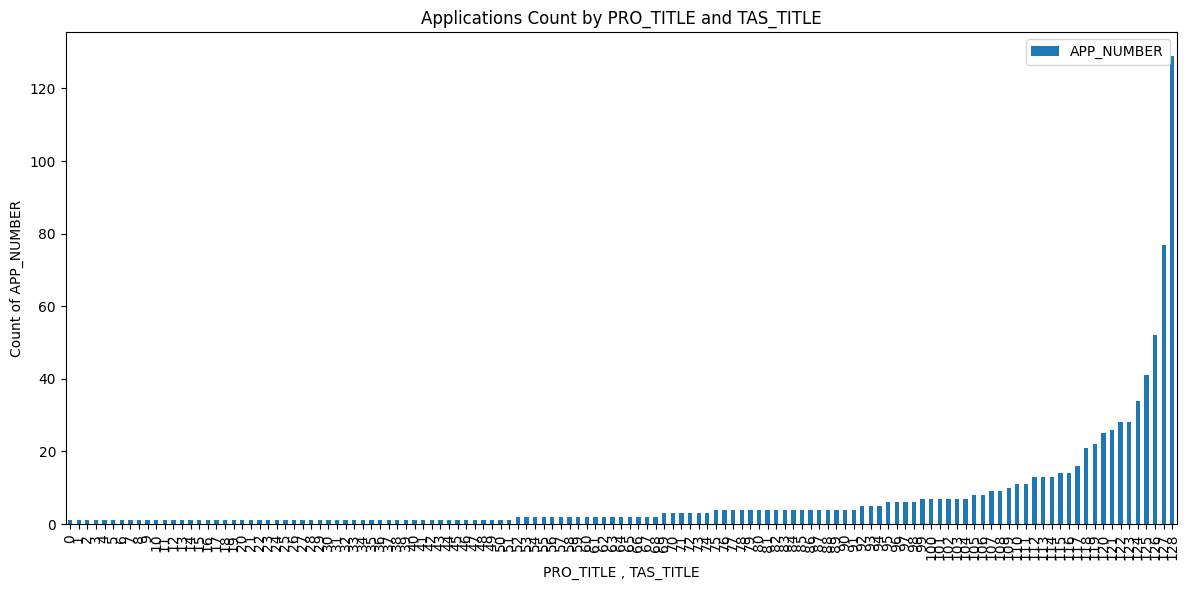

In [32]:
import matplotlib.pyplot as plt
df_p.plot(kind='bar', figsize=(12,6))

plt.xlabel('PRO_TITLE , TAS_TITLE')
plt.ylabel('Count of APP_NUMBER')
plt.title('Applications Count by PRO_TITLE and TAS_TITLE')

plt.tight_layout()
plt.show()